# E-Waste Profitability Prediction
## 01 — Data Understanding

Group: 2026-AI-14
Module: IT3091 — Machine Learning

### Primary objective
Predict the recorded profit of an e-waste item in USD.

### Secondary objective
Develop a High, Medium, or Low profit-based priority indicator
to support the primary profitability decision.

### Unit of analysis
One row represents one device/item record identified by device_id.
Whether these records represent operational batches must be
confirmed with the data provider.

### Scope limitations
The supplied dataset does not contain processing time, energy,
acid consumption, or contamination measurements.

The accounting definition of total_profit_usd and the availability
of metal-yield measurements before purchasing must be confirmed.

Libraries import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import hashlib
import platform
import sklearn

from google.colab import files
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.13.15
pandas: 2.2.3
NumPy: 2.1.3
scikit-learn: 1.6.1


Upload Original dataset

In [ ]:
uploaded = files.upload()

Saving e_waste_metal_dataset_20000_extended.csv to e_waste_metal_dataset_20000_extended (1).csv


Load Dataset

In [ ]:
csv_files = [
    name for name in uploaded
    if name.lower().endswith(".csv")
]

assert len(csv_files) == 1, "Upload exactly one CSV file."

dataset_filename = csv_files[0]

df = pd.read_csv(dataset_filename)

with open(dataset_filename, "rb") as file:
    dataset_sha256 = hashlib.sha256(file.read()).hexdigest()

print("Dataset filename:", dataset_filename)
print("Dataset shape:", df.shape)
print("SHA-256:", dataset_sha256)

display(df.head())

Dataset filename: e_waste_metal_dataset_20000_extended (1).csv
Dataset shape: (20000, 13)
SHA-256: e70b6ae3521a17ff47232fe9729d56aa7a6bea4a7599aec889738c6ff7534a98


,device_id,item_name,device_category,condition,weight_g,device_age_years,gold_yield_g,silver_yield_g,copper_yield_g,total_profit_usd,Acquisition_Cost_LKR,Hazardous_Flag,Casing_Material
0,DEV-00001,AMD Ryzen 7 5800X,Microprocessor,E-Waste / End-of-Life,31.05,9,0.2652,0.1661,10.68,9.25,2575.42,No,Plastic
1,DEV-00002,iPad Pro 11,Tablet,Used-Fair,489.90,6,0.0618,0.7373,42.43,3.75,26896.00,Yes,Aluminum
2,DEV-00003,Xiaomi Mi Router 4C,Wi-Fi Router,Used-Fair,329.22,4,0.0088,0.4331,23.04,0.88,2712.06,No,Plastic
3,DEV-00004,Seagate 500GB,Hard Disk Drive,Used-Good,480.40,8,0.0105,0.5577,53.26,1.56,3993.29,No,Aluminum
4,DEV-00005,AMD Ryzen 7 5800X,Microprocessor,New,52.07,8,0.3789,0.1625,5.27,33.40,7749.66,No,Plastic


Basic data quality

In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print(
    "Duplicate device IDs:",
    df["device_id"].duplicated().sum()
)

assert "total_profit_usd" in df.columns
assert df["device_id"].notna().all()
assert df["device_id"].is_unique
assert df["total_profit_usd"].notna().all()

Column names:
['device_id', 'item_name', 'device_category', 'condition', 'weight_g', 'device_age_years', 'gold_yield_g', 'silver_yield_g', 'copper_yield_g', 'total_profit_usd', 'Acquisition_Cost_LKR', 'Hazardous_Flag', 'Casing_Material']

Data types:
device_id                object
item_name                object
device_category          object
condition                object
weight_g                float64
device_age_years          int64
gold_yield_g            float64
silver_yield_g          float64
copper_yield_g          float64
total_profit_usd        float64
Acquisition_Cost_LKR    float64
Hazardous_Flag           object
Casing_Material          object
dtype: object

Missing values:
device_id               0
item_name               0
device_category         0
condition               0
weight_g                0
device_age_years        0
gold_yield_g            0
silver_yield_g          0
copper_yield_g          0
total_profit_usd        0
Acquisition_Cost_LKR    0
Hazardous_Flag  

Train/test split for detailed EDA and Preprocessing

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

train_df = train_df.copy()
test_df = test_df.copy()

assert set(train_df["device_id"]).isdisjoint(
    set(test_df["device_id"])
)

print("Training dataset:", train_df.shape)
print("Test dataset:", test_df.shape)

Training dataset: (16000, 13)
Test dataset: (4000, 13)


Data Dictionary.

In [ ]:
column_details = {
    "device_id": (
        "Unique device record identifier",
        "Identifier",
        "Exclude from model inputs"
    ),
    "item_name": (
        "Device/item name",
        "Text",
        "Keep for reference; exclude initially"
    ),
    "device_category": (
        "Device category",
        "Category",
        "Candidate input"
    ),
    "condition": (
        "Recorded device condition",
        "Category",
        "Candidate input"
    ),
    "weight_g": (
        "Recorded device weight",
        "Grams",
        "Candidate input"
    ),
    "device_age_years": (
        "Recorded device age",
        "Years",
        "Candidate input"
    ),
    "gold_yield_g": (
        "Recorded gold yield; estimate/actual timing needs confirmation",
        "Grams",
        "Input only if available before the decision"
    ),
    "silver_yield_g": (
        "Recorded silver yield; estimate/actual timing needs confirmation",
        "Grams",
        "Input only if available before the decision"
    ),
    "copper_yield_g": (
        "Recorded copper yield; estimate/actual timing needs confirmation",
        "Grams",
        "Input only if available before the decision"
    ),
    "total_profit_usd": (
        "Recorded profit; accounting definition needs confirmation",
        "USD",
        "Regression target"
    ),
    "Acquisition_Cost_LKR": (
        "Recorded acquisition cost",
        "LKR",
        "Input availability depends on decision stage"
    ),
    "Hazardous_Flag": (
        "Recorded hazardous indicator",
        "Category",
        "Candidate input; verify definition"
    ),
    "Casing_Material": (
        "Recorded casing material",
        "Category",
        "Candidate input"
    )
}

data_dictionary = pd.DataFrame([
    {
        "Column": column,
        "Description": column_details[column][0],
        "Unit_or_Type": column_details[column][1],
        "Role": column_details[column][2],
        "Data_Type": str(train_df[column].dtype),
        "Missing_Train": train_df[column].isna().sum(),
        "Unique_Train": train_df[column].nunique()
    }
    for column in train_df.columns
])

display(data_dictionary)

data_dictionary.to_csv(
    "data_dictionary.csv",
    index=False
)

,Column,Description,Unit_or_Type,Role,Data_Type,Missing_Train,Unique_Train
0,device_id,Unique device record identifier,Identifier,Exclude from model inputs,object,0,16000
1,item_name,Device/item name,Text,Keep for reference; exclude initially,object,0,57
2,device_category,Device category,Category,Candidate input,object,0,10
3,condition,Recorded device condition,Category,Candidate input,object,0,5
4,weight_g,Recorded device weight,Grams,Candidate input,float64,0,13134
5,device_age_years,Recorded device age,Years,Candidate input,int64,0,10
6,gold_yield_g,Recorded gold yield; estimate/actual timing ne...,Grams,Input only if available before the decision,float64,0,4005
7,silver_yield_g,Recorded silver yield; estimate/actual timing ...,Grams,Input only if available before the decision,float64,0,9066
8,copper_yield_g,Recorded copper yield; estimate/actual timing ...,Grams,Input only if available before the decision,float64,0,8203
9,total_profit_usd,Recorded profit; accounting definition needs c...,USD,Regression target,float64,0,3447


Summary statistics

In [ ]:
numeric_columns = train_df.select_dtypes(
    include="number"
).columns.tolist()

summary_statistics = (
    train_df[numeric_columns].describe().T
)

summary_statistics["missing_count"] = (
    train_df[numeric_columns].isna().sum()
)

display(summary_statistics)

summary_statistics.to_csv(
    "training_summary_statistics.csv"
)

,count,mean,std,min,25%,50%,75%,max,missing_count
weight_g,16000.0,446.979458,555.101737,10.000,53.1175,342.1400,511.585000,2499.7600,0
device_age_years,16000.0,4.525375,2.878910,0.000,2.0000,5.0000,7.000000,9.0000,0
gold_yield_g,16000.0,0.145398,0.213333,0.005,0.0149,0.0328,0.241125,0.9999,0
silver_yield_g,16000.0,0.763205,0.881100,0.050,0.1940,0.4479,0.919925,3.9988,0
copper_yield_g,16000.0,63.854626,89.662130,1.000,9.6675,31.1100,67.777500,399.9600,0
total_profit_usd,16000.0,8.846666,12.967467,0.220,1.2400,2.4400,12.812500,96.6600,0
Acquisition_Cost_LKR,16000.0,14056.118031,19820.346660,125.200,2686.3525,6793.3050,17518.822500,179914.8000,0


Category and condition counts


device_category


,column,value,count,percentage
0,device_category,Smartphone,1671,10.44
1,device_category,Smartwatch,1646,10.29
2,device_category,Microprocessor,1616,10.10
3,device_category,RAM Module,1597,9.98
4,device_category,Wi-Fi Router,1594,9.96
5,device_category,Desktop Motherboard,1590,9.94
6,device_category,Digital Camera,1579,9.87
7,device_category,Hard Disk Drive,1578,9.86
8,device_category,Tablet,1571,9.82
9,device_category,Laptop,1558,9.74



condition


,column,value,count,percentage
0,condition,Used-Good,4815,30.09
1,condition,Used-Fair,4740,29.62
2,condition,E-Waste / End-of-Life,3229,20.18
3,condition,Refurbished,2454,15.34
4,condition,New,762,4.76



Hazardous_Flag


,column,value,count,percentage
0,Hazardous_Flag,Yes,8756,54.72
1,Hazardous_Flag,No,7244,45.28



Casing_Material


,column,value,count,percentage
0,Casing_Material,Mixed Metal,6204,38.78
1,Casing_Material,Plastic,5115,31.97
2,Casing_Material,Aluminum,4681,29.26


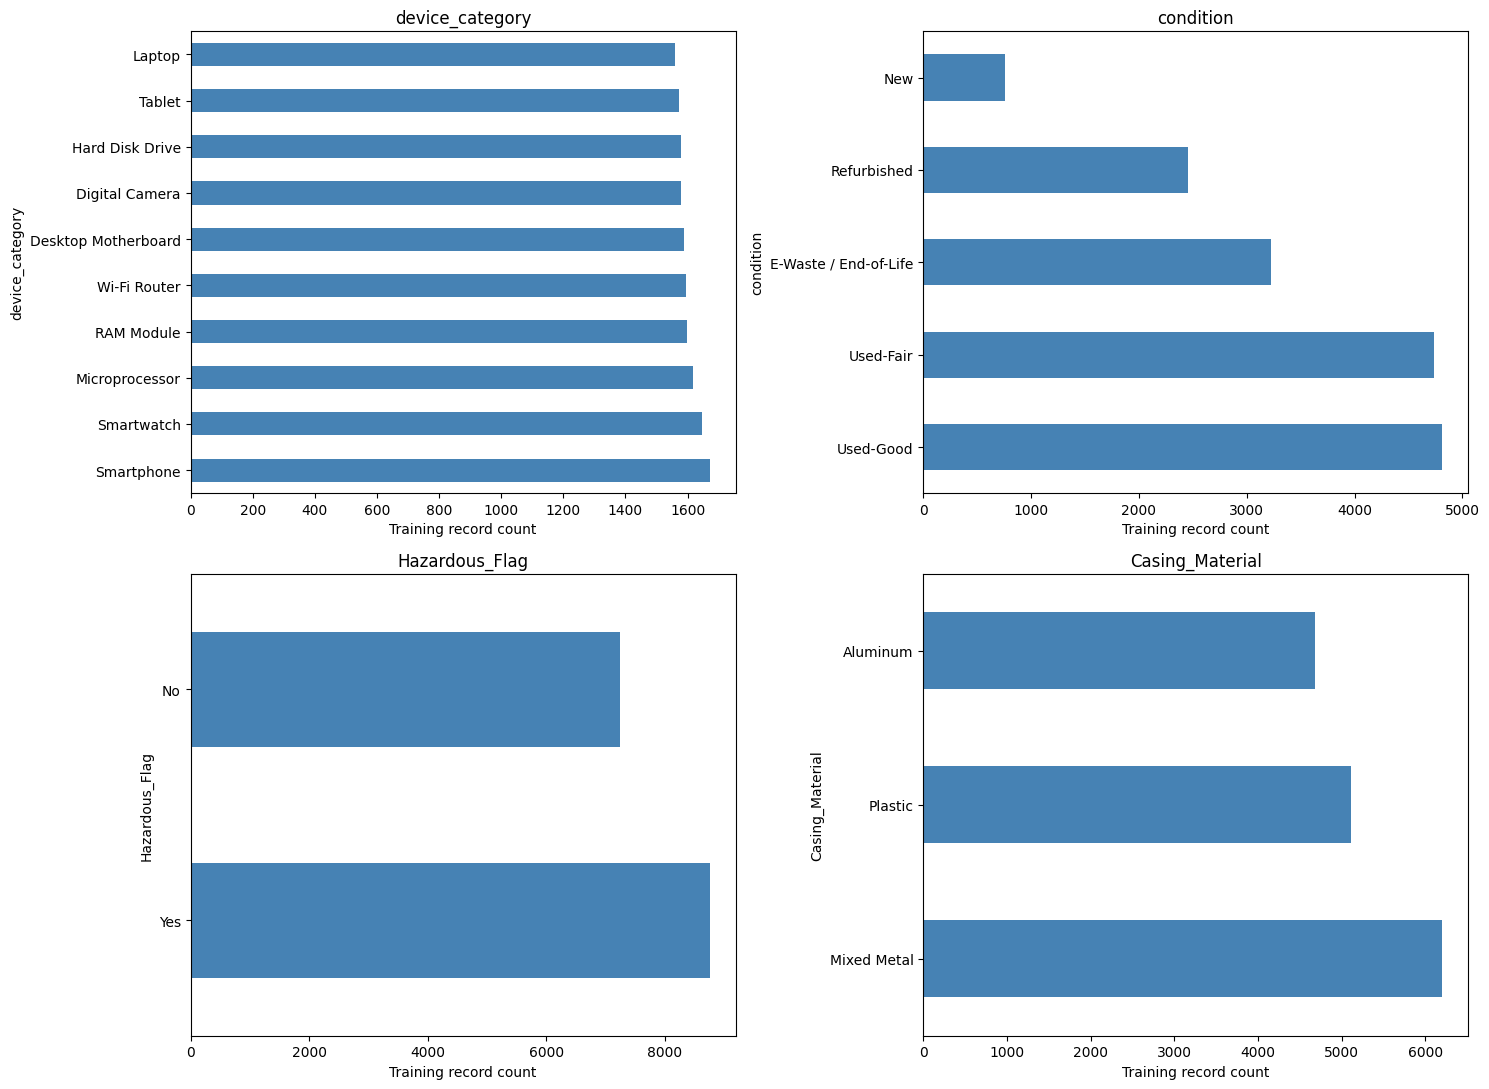

In [ ]:
categorical_columns = [
    "device_category",
    "condition",
    "Hazardous_Flag",
    "Casing_Material"
]

category_count_tables = []

for column in categorical_columns:
    counts = (
        train_df[column]
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="count")
    )

    counts["percentage"] = (
        counts["count"] / len(train_df) * 100
    ).round(2)

    counts.insert(0, "column", column)
    category_count_tables.append(counts)

    print(f"\n{column}")
    display(counts)

category_counts = pd.concat(
    category_count_tables,
    ignore_index=True
)

category_counts.to_csv(
    "training_category_counts.csv",
    index=False
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for column, ax in zip(
    categorical_columns,
    axes.flatten()
):
    counts = train_df[column].value_counts()
    counts.plot.barh(ax=ax, color="steelblue")
    ax.set_title(column)
    ax.set_xlabel("Training record count")

plt.tight_layout()
plt.savefig("category_counts.png", dpi=150)
plt.show()

Numerical distributions and skewness

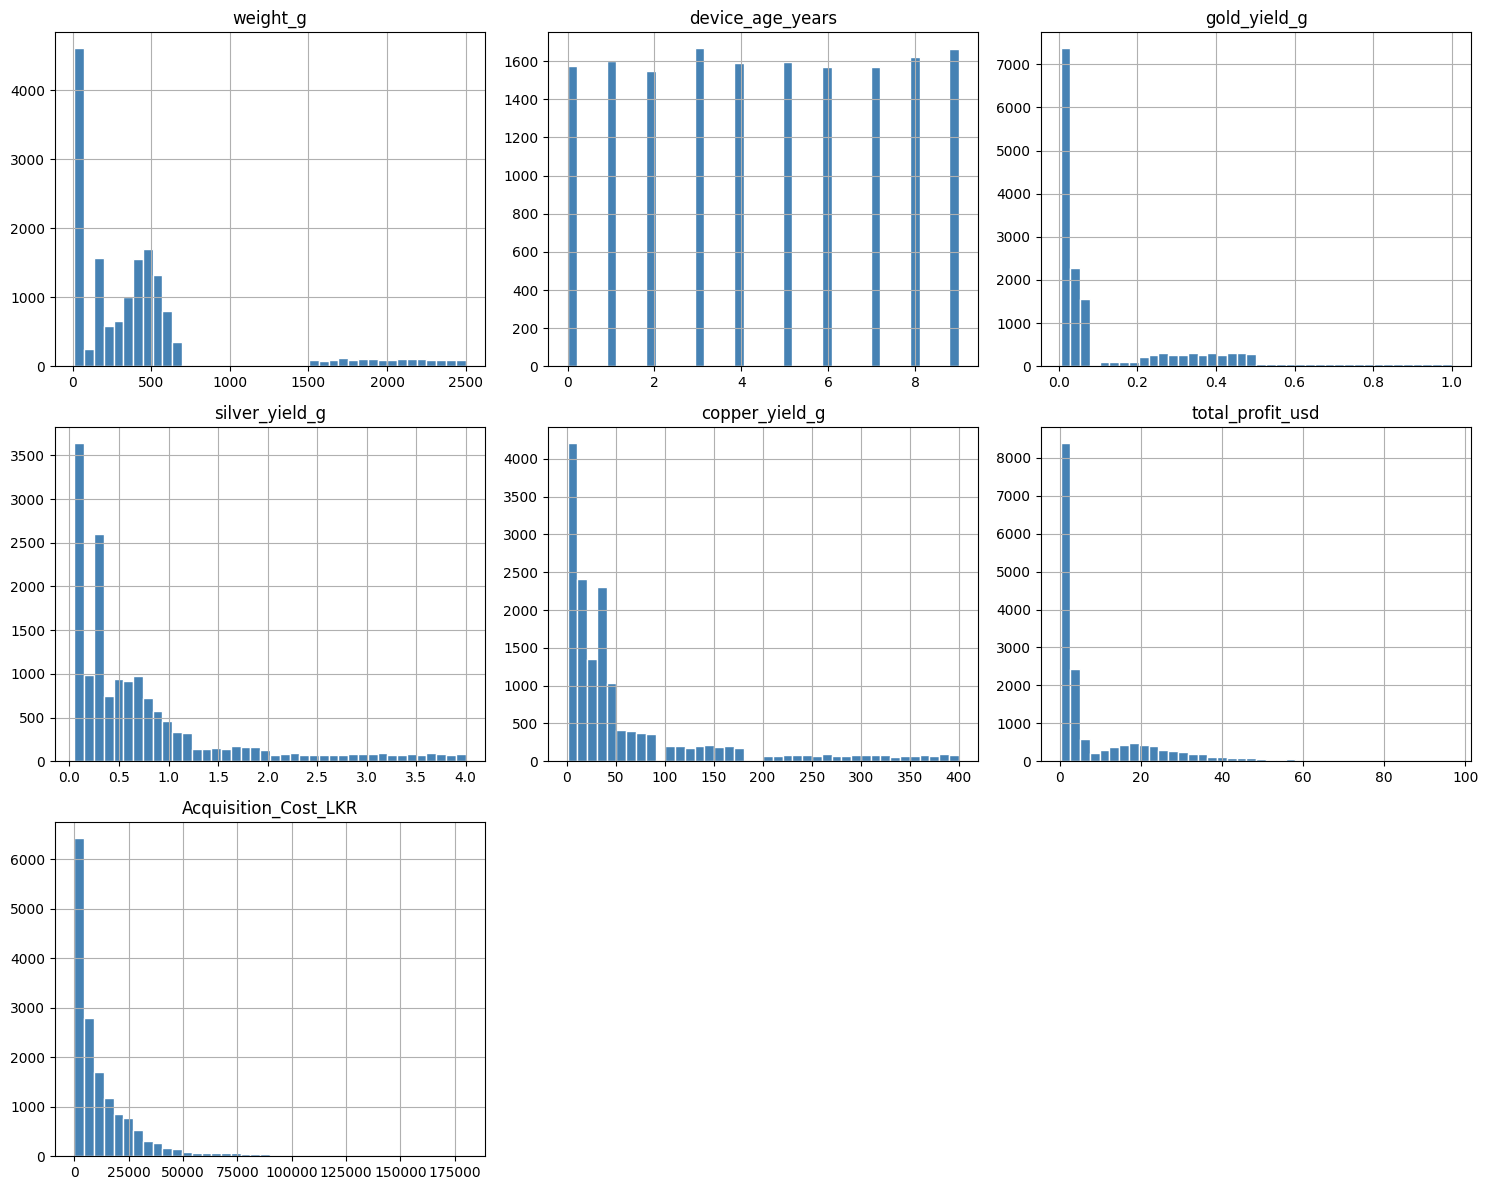

,skewness,absolute_skewness
Acquisition_Cost_LKR,3.191254,3.191254
weight_g,2.215069,2.215069
total_profit_usd,2.162711,2.162711
copper_yield_g,2.114143,2.114143
silver_yield_g,1.901334,1.901334
gold_yield_g,1.870113,1.870113
device_age_years,-0.001941,0.001941


In [ ]:
train_df[numeric_columns].hist(
    bins=40,
    figsize=(15, 12),
    color="steelblue",
    edgecolor="white"
)

plt.tight_layout()
plt.savefig("numerical_distributions.png", dpi=150)
plt.show()

skewness_table = (
    train_df[numeric_columns]
    .skew()
    .rename("skewness")
    .to_frame()
)

skewness_table["absolute_skewness"] = (
    skewness_table["skewness"].abs()
)

skewness_table = skewness_table.sort_values(
    "absolute_skewness",
    ascending=False
)

display(skewness_table)

skewness_table.to_csv("training_skewness.csv")

Profit distribution and category  profit

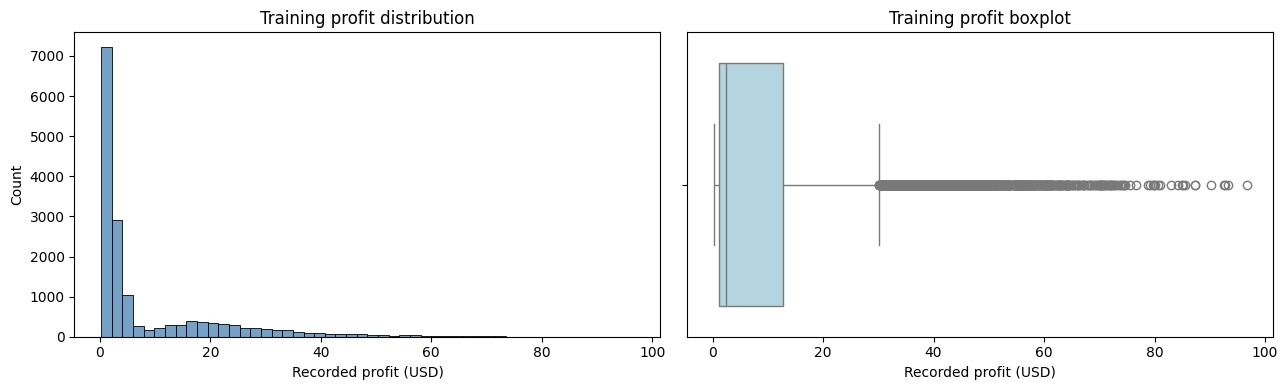

Negative-profit records: 0
Zero-profit records: 0


,count,mean,median,std,min,max
device_category,,,,,,
Desktop Motherboard,1590,36.378440,34.330,15.292893,10.68,96.66
Laptop,1558,22.247035,20.690,7.718276,8.81,51.92
Microprocessor,1616,16.478942,15.455,7.784998,3.46,45.86
Tablet,1571,4.235939,4.150,1.180657,2.12,8.67
Digital Camera,1579,3.220874,3.120,0.981119,1.52,6.99
Smartphone,1671,1.920281,1.860,0.522344,1.02,3.70
Hard Disk Drive,1578,1.887649,1.820,0.537469,0.91,3.88
RAM Module,1597,1.283369,1.240,0.400505,0.54,2.82
Wi-Fi Router,1594,1.033595,0.990,0.328129,0.43,2.31


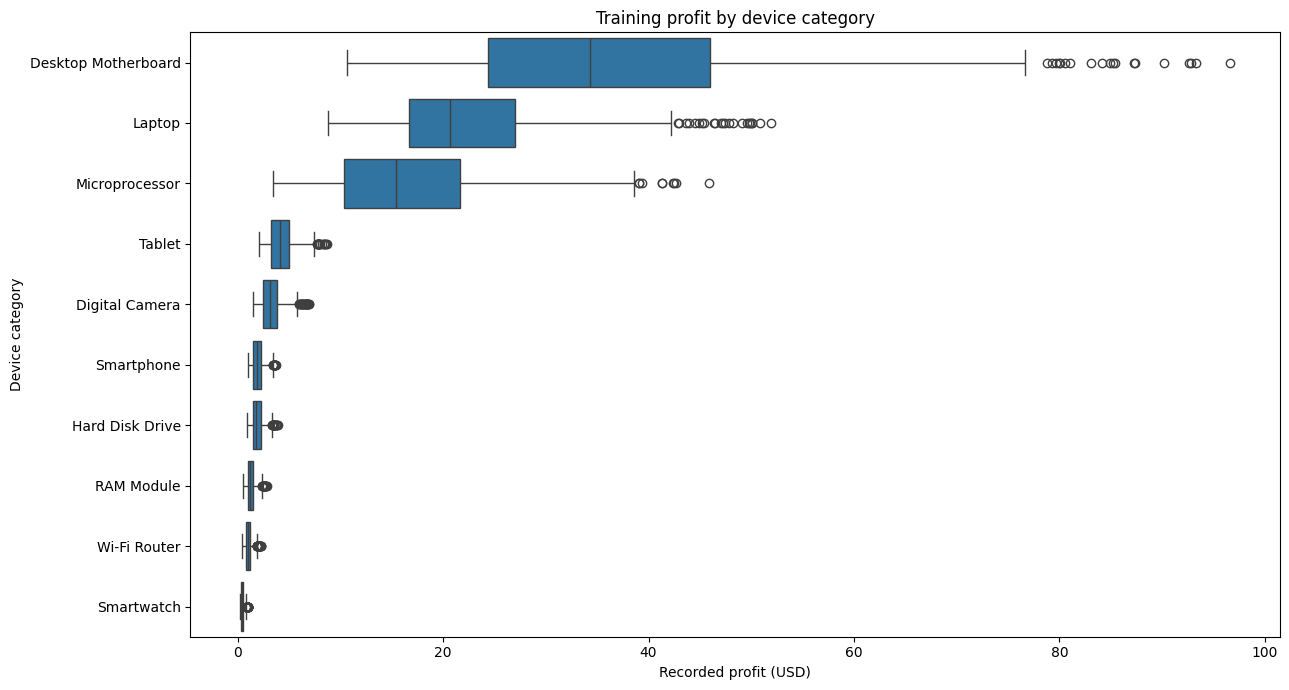

In [ ]:
profit = train_df["total_profit_usd"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(
    profit,
    bins=50,
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Training profit distribution")
axes[0].set_xlabel("Recorded profit (USD)")

sns.boxplot(
    x=profit,
    ax=axes[1],
    color="lightblue"
)
axes[1].set_title("Training profit boxplot")
axes[1].set_xlabel("Recorded profit (USD)")

plt.tight_layout()
plt.savefig("profit_distribution.png", dpi=150)
plt.show()

print("Negative-profit records:", int((profit < 0).sum()))
print("Zero-profit records:", int((profit == 0).sum()))

category_profit = (
    train_df.groupby("device_category")["total_profit_usd"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("median", ascending=False)
)

display(category_profit)

category_profit.to_csv("training_category_profit.csv")

order = category_profit.index.tolist()

plt.figure(figsize=(13, 7))

sns.boxplot(
    data=train_df,
    x="total_profit_usd",
    y="device_category",
    order=order
)

plt.xlabel("Recorded profit (USD)")
plt.ylabel("Device category")
plt.title("Training profit by device category")
plt.tight_layout()
plt.savefig("profit_by_category.png", dpi=150)
plt.show()

Outliers and physical plausibility

In [ ]:
outlier_rows = []

for column in numeric_columns:
    values = train_df[column].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flagged = (
        (train_df[column] < lower) |
        (train_df[column] > upper)
    )

    outlier_rows.append({
        "feature": column,
        "lower_bound": lower,
        "upper_bound": upper,
        "flagged_count": int(flagged.sum()),
        "flagged_percentage": round(
            flagged.mean() * 100, 2
        )
    })

outlier_summary = pd.DataFrame(outlier_rows)

display(outlier_summary)

outlier_summary.to_csv(
    "training_iqr_flags.csv",
    index=False
)

,feature,lower_bound,upper_bound,flagged_count,flagged_percentage
0,weight_g,-634.583750,1199.286250,1558,9.74
1,device_age_years,-5.500000,14.500000,0,0.00
2,gold_yield_g,-0.324437,0.580462,861,5.38
3,silver_yield_g,-0.894887,2.008812,1585,9.91
4,copper_yield_g,-77.497500,154.942500,2042,12.76
5,total_profit_usd,-16.118750,30.171250,1301,8.13
6,Acquisition_Cost_LKR,-19562.352500,39767.527500,1166,7.29


measurement consistency

In [ ]:
metal_columns = [
    "gold_yield_g",
    "silver_yield_g",
    "copper_yield_g"
]

measurement_columns = [
    "weight_g",
    "device_age_years",
    "Acquisition_Cost_LKR"
] + metal_columns

negative_measurement = (
    train_df[measurement_columns] < 0
).any(axis=1)

invalid_weight = train_df["weight_g"] <= 0

total_metal_g = train_df[metal_columns].sum(
    axis=1,
    min_count=len(metal_columns)
)

metal_exceeds_weight = (
    total_metal_g > train_df["weight_g"]
)

nonfinite_numeric = ~np.isfinite(
    train_df[numeric_columns]
).all(axis=1)

plausibility_summary = pd.DataFrame({
    "check": [
        "Negative input measurement",
        "Zero or negative weight",
        "Total metal yield exceeds device weight",
        "Missing or non-finite numeric value"
    ],
    "flagged_count": [
        int(negative_measurement.sum()),
        int(invalid_weight.sum()),
        int(metal_exceeds_weight.sum()),
        int(nonfinite_numeric.sum())
    ]
})

display(plausibility_summary)

plausibility_summary.to_csv(
    "physical_plausibility_summary.csv",
    index=False
)

flagged_records = train_df.loc[
    negative_measurement |
    invalid_weight |
    metal_exceeds_weight |
    nonfinite_numeric
].copy()

flagged_records.to_csv(
    "records_for_source_review.csv",
    index=False
)

display(flagged_records.head(10))

,check,flagged_count
0,Negative input measurement,0
1,Zero or negative weight,0
2,Total metal yield exceeds device weight,0
3,Missing or non-finite numeric value,0


,device_id,item_name,device_category,condition,weight_g,device_age_years,gold_yield_g,silver_yield_g,copper_yield_g,total_profit_usd,Acquisition_Cost_LKR,Hazardous_Flag,Casing_Material


Correlation matrix

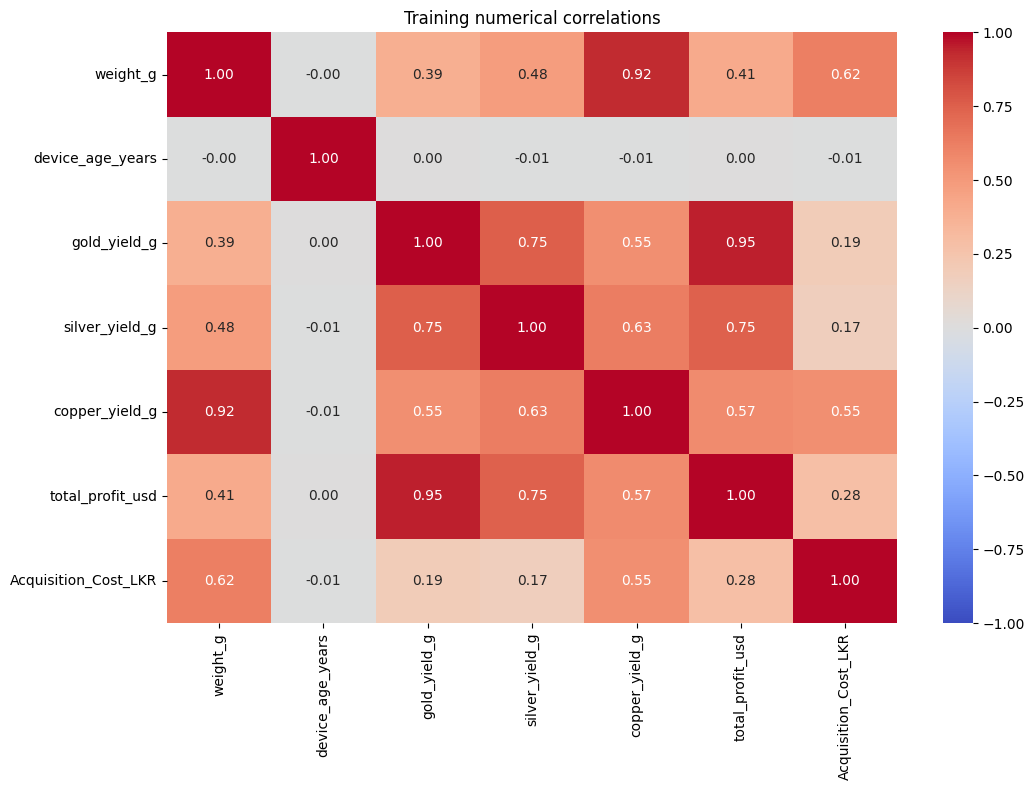

,correlation_with_profit,absolute_correlation
gold_yield_g,0.951170,0.951170
silver_yield_g,0.749136,0.749136
copper_yield_g,0.568375,0.568375
weight_g,0.412198,0.412198
Acquisition_Cost_LKR,0.284168,0.284168
device_age_years,0.001255,0.001255


In [ ]:
correlation_matrix = (
    train_df[numeric_columns].corr()
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Training numerical correlations")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150)
plt.show()

correlation_matrix.to_csv(
    "training_correlation_matrix.csv"
)

target_correlations = (
    correlation_matrix["total_profit_usd"]
    .drop("total_profit_usd")
    .rename("correlation_with_profit")
    .to_frame()
)

target_correlations["absolute_correlation"] = (
    target_correlations["correlation_with_profit"].abs()
)

target_correlations = target_correlations.sort_values(
    "absolute_correlation",
    ascending=False
)

display(target_correlations)

target_correlations.to_csv(
    "correlation_with_profit.csv"
)

Test VIF

In [ ]:
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)
from statsmodels.tools.tools import add_constant

vif_features = [
    column for column in numeric_columns
    if column != "total_profit_usd"
]

vif_input = (
    train_df[vif_features]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# Constant predictors cannot provide useful VIF estimates.
vif_input = vif_input.loc[
    :, vif_input.nunique() > 1
]

vif_design = add_constant(
    vif_input.astype(float),
    has_constant="add"
)

vif_table = pd.DataFrame({
    "feature": vif_input.columns,
    "VIF": [
        variance_inflation_factor(
            vif_design.to_numpy(),
            i
        )
        for i in range(1, vif_design.shape[1])
    ]
}).sort_values("VIF", ascending=False)

print("Complete training rows used:", len(vif_input))

display(vif_table)

vif_table.to_csv(
    "training_vif.csv",
    index=False
)

Complete training rows used: 16000


,feature,VIF
4,copper_yield_g,10.734528
0,weight_g,9.094280
3,silver_yield_g,2.887590
2,gold_yield_g,2.534895
5,Acquisition_Cost_LKR,1.716412
1,device_age_years,1.000185


EDA Insight Log

In [ ]:
strongest_feature = target_correlations.index[0]

strongest_correlation = target_correlations.loc[
    strongest_feature,
    "correlation_with_profit"
]

most_skewed_feature = skewness_table.index[0]

highest_median_category = category_profit.index[0]

high_vif_features = vif_table.loc[
    vif_table["VIF"] > 5,
    "feature"
].tolist()

profit_flag_count = int(
    outlier_summary.loc[
        outlier_summary["feature"] == "total_profit_usd",
        "flagged_count"
    ].iloc[0]
)

eda_insight_log = pd.DataFrame([
    {
        "topic": "Target distribution",
        "observed_evidence": (
            f"Profit skewness = {profit.skew():.3f}; "
            f"IQR-flagged records = {profit_flag_count}"
        ),
        "modeling_implication": (
            "Compare MAE and RMSE; review large errors; "
            "retain valid high-value records."
        )
    },
    {
        "topic": "Numerical skewness",
        "observed_evidence": (
            f"Highest absolute skewness: {most_skewed_feature}"
        ),
        "modeling_implication": (
            "Consider justified transformations in feature "
            "engineering and compare validation performance."
        )
    },
    {
        "topic": "Profit association",
        "observed_evidence": (
            f"Strongest absolute numerical correlation: "
            f"{strongest_feature}, r={strongest_correlation:.3f}"
        ),
        "modeling_implication": (
            "Useful candidate predictor; verify availability "
            "before the business decision. Association is not causation."
        )
    },
    {
        "topic": "Multicollinearity",
        "observed_evidence": (
            f"Numerical predictors with VIF > 5: {high_vif_features}"
        ),
        "modeling_implication": (
            "Interpret linear coefficients cautiously; "
            "do not automatically delete predictors."
        )
    },
    {
        "topic": "Category differences",
        "observed_evidence": (
            f"Highest median recorded profit category: "
            f"{highest_median_category}"
        ),
        "modeling_implication": (
            "Include category as a candidate input and "
            "evaluate errors separately by category."
        )
    },
    {
        "topic": "Loss examples",
        "observed_evidence": (
            f"Negative-profit training records: "
            f"{int((profit < 0).sum())}"
        ),
        "modeling_implication": (
            "If absent, loss-detection performance cannot "
            "be validated using this sample."
        )
    },
    {
        "topic": "Physical consistency",
        "observed_evidence": (
            f"Metal yield exceeds weight in "
            f"{int(metal_exceeds_weight.sum())} training records"
        ),
        "modeling_implication": (
            "Confirm units and measurement definitions "
            "with the provider before cleaning."
        )
    }
])

display(eda_insight_log)

eda_insight_log.to_csv(
    "eda_insight_log.csv",
    index=False
)

,topic,observed_evidence,modeling_implication
0,Target distribution,Profit skewness = 2.163; IQR-flagged records =...,Compare MAE and RMSE; review large errors; ret...
1,Numerical skewness,Highest absolute skewness: Acquisition_Cost_LKR,Consider justified transformations in feature ...
2,Profit association,Strongest absolute numerical correlation: gold...,Useful candidate predictor; verify availabilit...
3,Multicollinearity,Numerical predictors with VIF > 5: ['copper_yi...,Interpret linear coefficients cautiously; do n...
4,Category differences,Highest median recorded profit category: Deskt...,Include category as a candidate input and eval...
5,Loss examples,Negative-profit training records: 0,"If absent, loss-detection performance cannot b..."
6,Physical consistency,Metal yield exceeds weight in 0 training records,Confirm units and measurement definitions with...


Source and limitations

## Data provenance and limitations

### Source verification
- Data provider: Pending confirmation/evidence.
- Collection method and collection period: Pending confirmation.
- Permission and anonymisation: Pending supporting evidence.
- Industry Explorer scope approval: Pending supporting evidence.
- Stakeholder feedback: To be collected after evaluation.

### Unit of analysis
The CSV identifies device/item records using device_id.
The proposal describes batches. The group must confirm the
relationship between item records and operational batches.

### Target definition
total_profit_usd is the recorded regression target.
Its accounting definition, including whether acquisition and
operating costs are included, requires provider confirmation.

### Input availability and leakage
Metal yields must be available as estimates before the intended
decision to qualify as predictors. Actual post-recycling yields
would not be available for a pre-purchase prediction.

Acquisition cost availability depends on the decision stage.
A final purchase price may be unavailable during initial bidding.

device_id is an identifier and will not be used as a predictor.
item_name will initially be excluded.

### Missing operational information
Processing time, energy, acid consumption and contamination
measurements are absent from the supplied CSV.

A profit-based High/Medium/Low tier is a proxy and does not
establish operational scheduling performance.

### Currency
Acquisition_Cost_LKR and total_profit_usd use different currencies.
They must not be directly subtracted without a documented,
date-appropriate exchange rate and verified accounting logic.

### Validation
The same 80/20 random split with random_state=42 will be used
across models. Detailed EDA uses training records only.

The random split does not establish performance on future
periods, new suppliers or new facilities.

### Statistical assumptions
Input distributions and VIF provide preliminary diagnostics.
Linear-model residual assumptions will be examined after fitting.

Datasets and evidence download

In [ ]:
import json

train_df.to_csv("train_raw.csv", index=False)
test_df.to_csv("test_raw.csv", index=False)

split_manifest = pd.concat([
    train_df[["device_id"]].assign(split="train"),
    test_df[["device_id"]].assign(split="test")
], ignore_index=True)

split_manifest.to_csv(
    "split_manifest.csv",
    index=False
)

manifest = {
    "dataset_filename": dataset_filename,
    "source_sha256": dataset_sha256,
    "random_state": 42,
    "test_fraction": 0.20,
    "training_rows": len(train_df),
    "test_rows": len(test_df),
    "target": "total_profit_usd",
    "python_version": platform.python_version(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "sklearn_version": sklearn.__version__
}

with open("dataset_manifest.json", "w") as file:
    json.dump(manifest, file, indent=2)

print("Training and test datasets saved.")
print("Original values retained; no preprocessing applied.")

Training and test datasets saved.
Original values retained; no preprocessing applied.


In [ ]:
files.download("train_raw.csv")
files.download("test_raw.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("data_dictionary.csv")
files.download("eda_insight_log.csv")
files.download("split_manifest.csv")
files.download("dataset_manifest.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>